In [1]:
import os
import gc
import csv
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision.io import read_image
from torchvision import models
from torchvision.transforms import v2 as transforms
from torch.utils.data import Dataset, SubsetRandomSampler
from safetensors.torch import save_model, load_model
import torchvision.transforms.functional as F

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
class SquarePad:
    def __call__(self, image):
        c, h, w = image.size()
        max_wh = np.max([w, h])
        hp = (max_wh - w) // 2 + max_wh // 10
        vp = (max_wh - h) // 2 + max_wh // 10
        padding = (hp, vp, hp, vp)
        return F.pad(image, padding, 1, 'constant')


def image_transform():
    return transforms.Compose([
        transforms.ConvertImageDtype(torch.float),
        transforms.RGB(),
        SquarePad(),
        transforms.Resize((224,224)),
        transforms.Lambda(lambda x: torch.clamp(x, 0, 1))
    ])


def load_image(path):
    transform = image_transform()
    image = read_image(path)
    image = transform(image)
    return image

In [4]:
def compute_similarity(image_path, embeddings, model):
    image = load_image(image_path)
    encoded = model.to(device)(image.unsqueeze(0).to(device)).detach()

    similarity_fn = nn.CosineSimilarity()
    def similarity(other_enc):
        return similarity_fn(encoded, other_enc)
    similarity_vec = torch.vmap(similarity)
    return similarity_vec(embeddings)


# Returns ([float], [str])
# tuple of similarity values and image paths (not sorted)
def calculate_similarity(model, embeddings, embeddings_paths, image_path):
    similarities = compute_similarity(image_path, embeddings, model).cpu().numpy().flatten()
    return similarities, embeddings_paths

In [5]:
embeddings = torch.load('../models/logos_embedding_tuned.pt')
embeddings_paths = pd.read_csv('../models/logos_embedding_tuned.csv', header=None, index_col=None)[0].tolist()
len(embeddings_paths)

100000

In [6]:
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT).to(device)
model.eval()
load_model(model, '../models/similarity.safetensors')
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

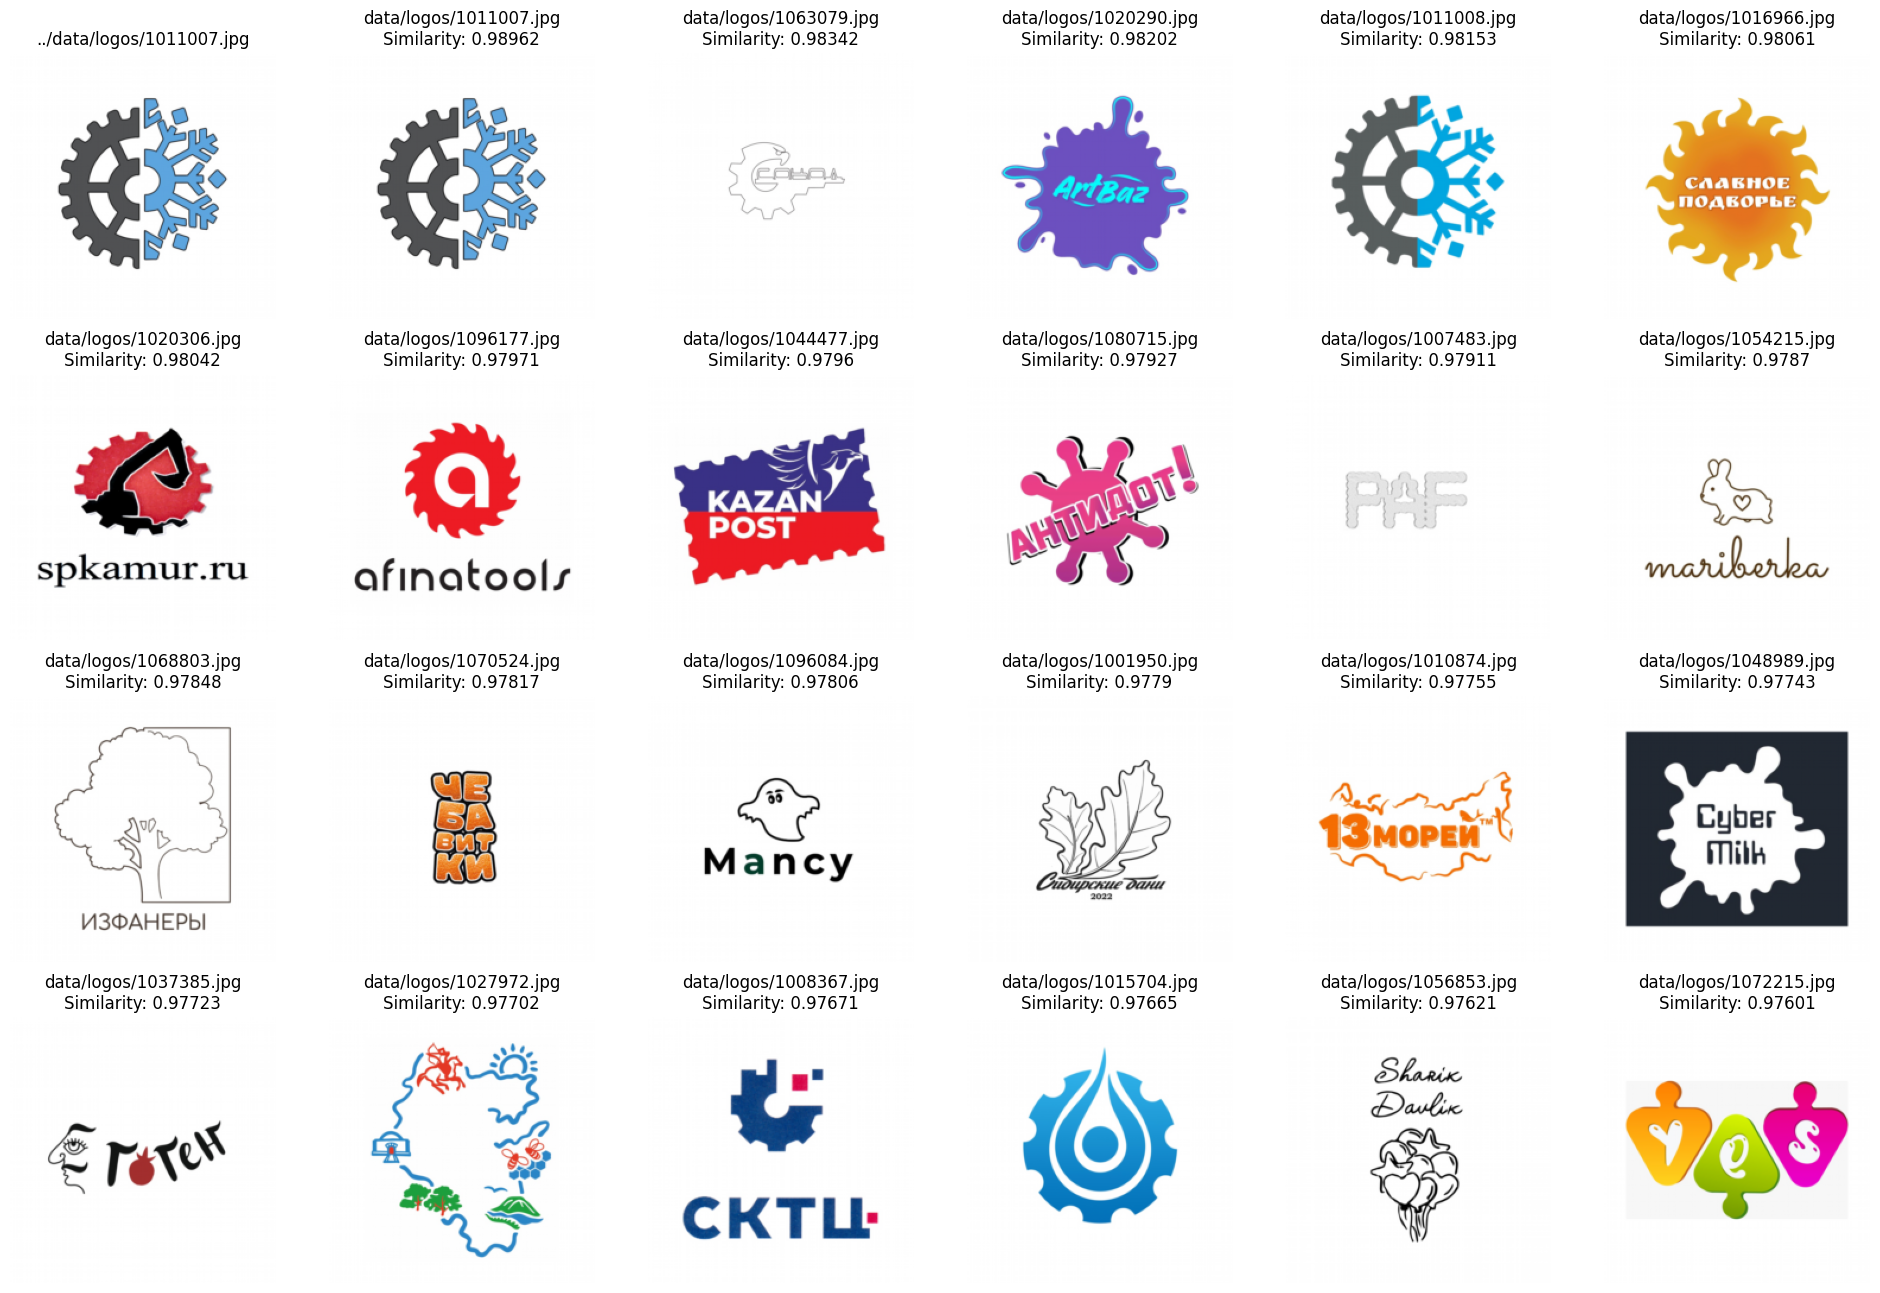

In [41]:
# Check a specific image
w, h = 6, 4
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

#img_path = '../data/logos/1074498.jpg' # bear
#img_path = '../data/logos/1018899.jpg' # dog булкин хвост
#img_path = '../data/logos/1007964.jpg' # fried chicken
#img_path = '../data/logos/1085495.jpg' # bipedal dog
#img_path = '../data/logos/1031647.jpg' # sitting bear?
#img_path = '../data/logos/1014250.jpg' # duck sitting at a table
img_path = '../data/logos/1011007.jpg'

similarities = compute_similarity(img_path, embeddings, model).cpu().numpy().flatten()
top_images = np.argsort(similarities)[::-1]

i = 0
for ax_row in axs:
    for ax in ax_row:
        if i == 0:
            img = load_image(img_path)
            ax.set_title(f'{img_path}')
        else:
            idx = top_images[i - 1]
            path = embeddings_paths[idx]
            img = load_image('../' + path)
            similarity = similarities[idx]
            ax.set_title(f'{path}\nSimilarity: {similarity:.5}')
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))
        i += 1

plt.show()